In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [3]:
tickers = ['KWEB', 'LIT', 'URA']

df = yf.download(tickers, start = "2015-01-01", end = "2025-01-01", interval = '1wk')['Close']

df.dropna(inplace=True)

print(df)

C:\Users\giann\AppData\Local\Temp\ipykernel_57860\2800389060.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start = "2015-01-01", end = "2025-01-01", interval = '1wk')['Close']
[*********************100%***********************]  3 of 3 completed

Ticker           KWEB        LIT        URA
Date                                       
2015-01-01  28.233440  19.109716  16.572893
2015-01-08  27.440838  19.179142  15.215190
2015-01-15  28.233440  19.370068  15.303732
2015-01-22  28.250132  19.352713  15.052854
2015-01-29  28.325216  19.335354  15.451309
...               ...        ...        ...
2024-11-28  29.622967  43.062935  30.844595
2024-12-05  31.063511  43.986774  30.036482
2024-12-12  28.791513  41.692078  27.066910
2024-12-19  30.080000  42.456974  27.339527
2024-12-26  29.240000  40.509953  26.073809

[522 rows x 3 columns]


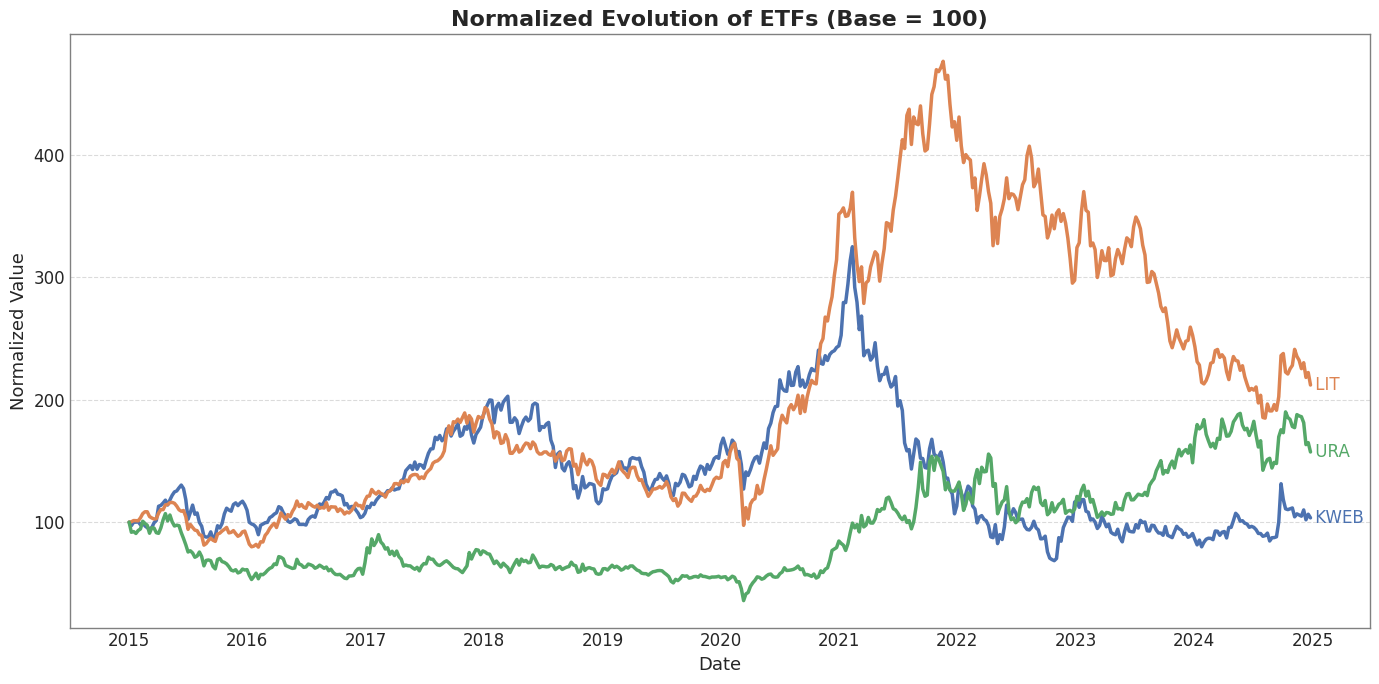

In [4]:
normalized = df/df.iloc[0] * 100

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'axes.titleweight': 'bold',
    'axes.edgecolor': 'gray'
})

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#4c72b0', '#dd8452', '#55a868']  # Custom soft palette

for i, column in enumerate(normalized.columns):
    ax.plot(normalized.index, normalized[column], color=colors[i], linewidth=2.5)
    ax.text(normalized.index[-1], normalized[column].iloc[-1], f' {column}', 
            color=colors[i], fontsize=12, va='center')

# Labels and styling
ax.set_title("Normalized Evolution of ETFs (Base = 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized Value")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

In [5]:
returns = np.log(df/df.shift(1))

returns = returns.dropna()

In [6]:
import scipy.stats as stats

descriptivestats = returns.describe().T
descriptivestats['skewness'] = returns.skew()
descriptivestats['kurtosis'] = returns.kurtosis()

descriptivestats = descriptivestats[['mean', 'std', 'skewness', 'kurtosis', 'max', 'min']]

descriptivestats

,mean,std,skewness,kurtosis,max,min
Ticker,,,,,,
KWEB,0.000067,0.050637,0.170412,2.640222,0.270973,-0.171936
LIT,0.001442,0.040340,-0.600189,4.086104,0.153490,-0.262523
URA,0.000870,0.052691,-0.007033,2.048535,0.200709,-0.237428


C:\Users\giann\AppData\Local\Temp\ipykernel_57860\566835406.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


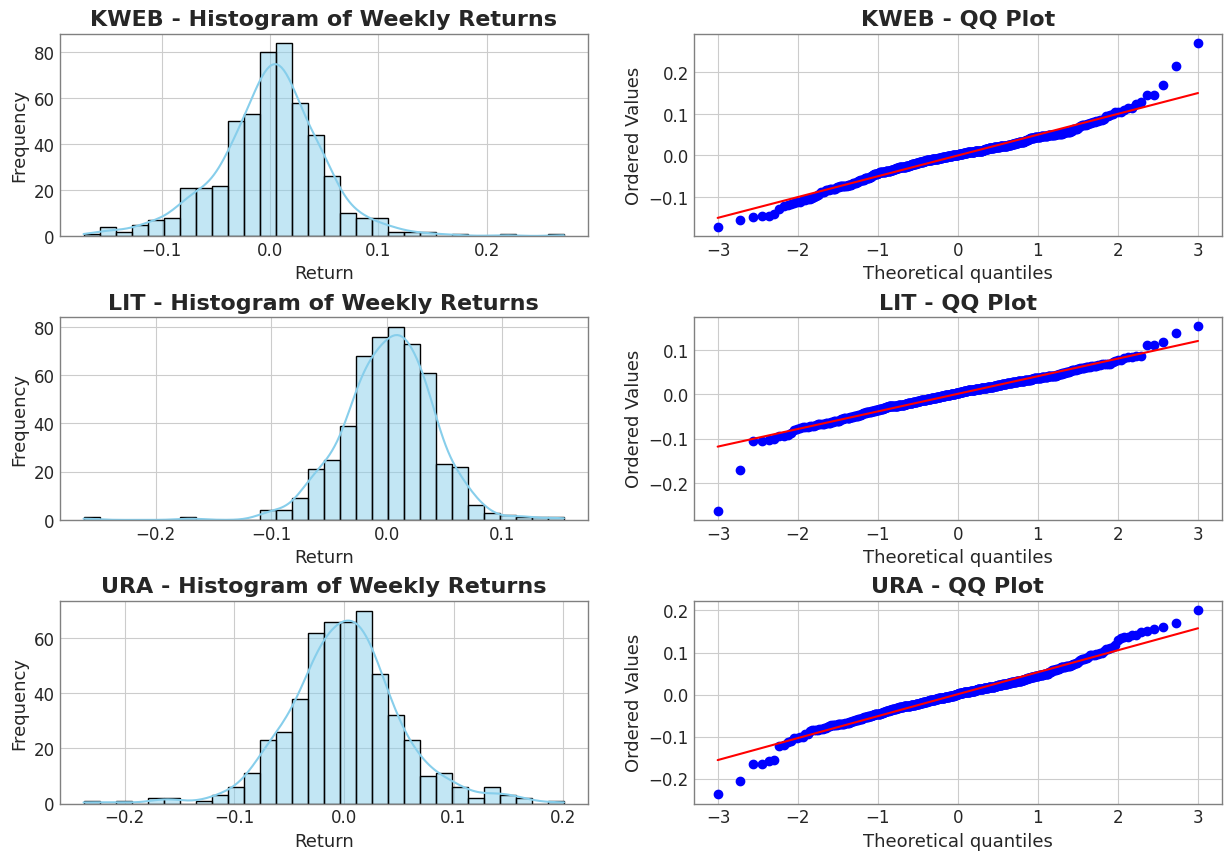

In [8]:
import matplotlib.gridspec as gridspec
import seaborn as sns

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 2, hspace=0.4)

for i, etf in enumerate(returns.columns):
    r = returns[etf]

    # Histogram
    ax_hist = fig.add_subplot(gs[i, 0])
    sns.histplot(r, kde=True, bins=30, ax=ax_hist, color='skyblue')
    ax_hist.set_title(f"{etf} - Histogram of Weekly Returns")
    ax_hist.set_xlabel("Return")
    ax_hist.set_ylabel("Frequency")

    ax_qq = fig.add_subplot(gs[i, 1])
    stats.probplot(r, dist="norm", plot=ax_qq)
    ax_qq.set_title(f"{etf} - QQ Plot")

plt.tight_layout()
plt.show()

In [9]:
from scipy.stats import jarque_bera

jb_results = {}

for etf in returns.columns:
    r = returns[etf]
    jb_stat, p_value = jarque_bera(r)
    jb_results[etf] = {
        "JB Result": jb_stat,
        "p-value": p_value,
        "Normality rejected (5%)": p_value < 0.05
    }

jb_results

jb_df = pd.DataFrame(jb_results).T

print(jb_df.round(3))


       JB Result p-value Normality rejected (5%)
KWEB   149.64605     0.0                    True
LIT   384.625702     0.0                    True
URA     88.35801     0.0                    True


In [10]:
corr_matrix = returns.corr()

print(corr_matrix.round(3))

Ticker   KWEB    LIT    URA
Ticker                     
KWEB    1.000  0.587  0.409
LIT     0.587  1.000  0.516
URA     0.409  0.516  1.000


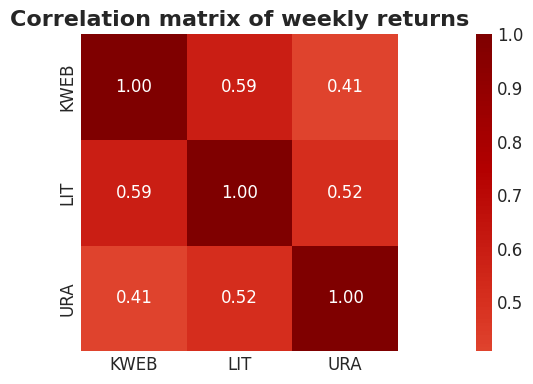

In [11]:
plt.figure(figsize=(16,4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="OrRd", center=0, square=True)
plt.title("Correlation matrix of weekly returns")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

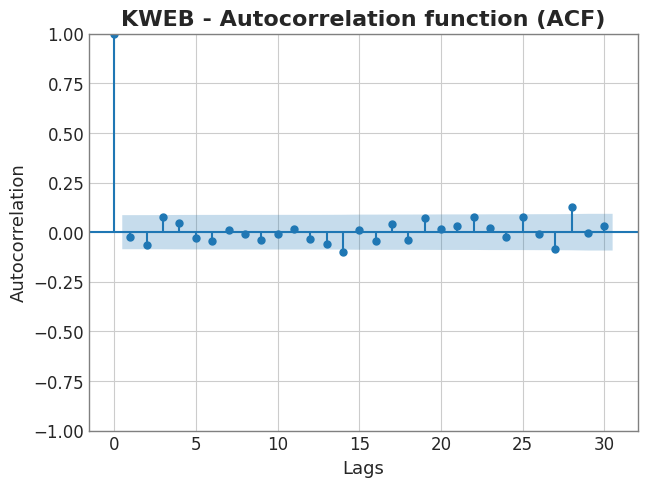

<Figure size 800x400 with 0 Axes>

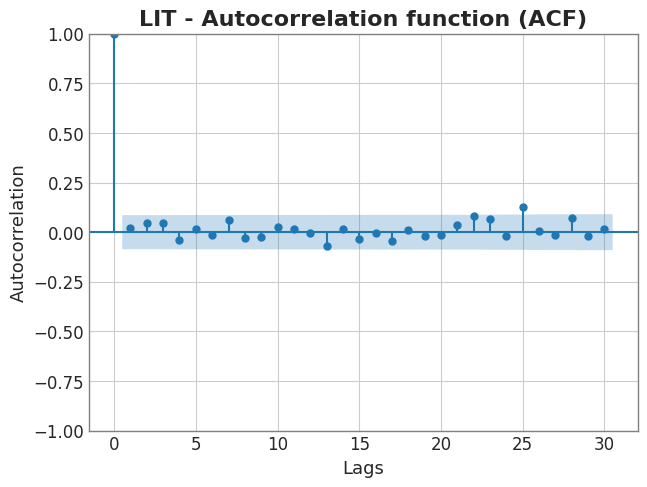

<Figure size 800x400 with 0 Axes>

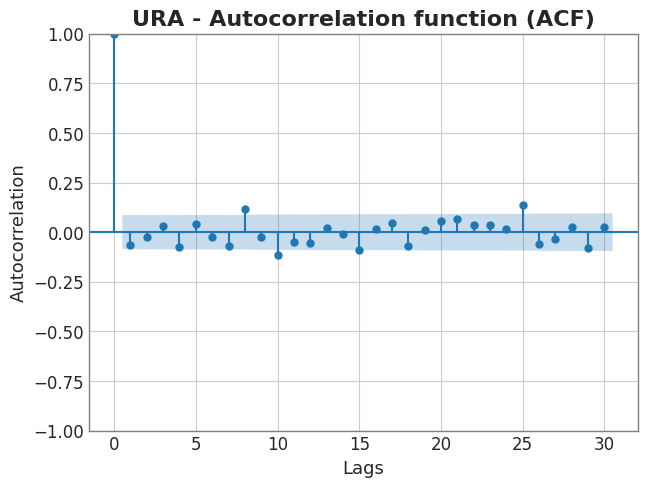

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

lags = 30

for etf in returns.columns:
    plt.figure(figsize=(8,4))
    plot_acf(returns[etf], lags = lags, alpha = 0.05, title = f"{etf} - Autocorrelation function (ACF)")
    plt.tight_layout()
    plt.xlabel('Lags')
    plt.ylabel('Autocorrelation')
    plt.show()

In [21]:
log_prices = np.log(df)

etfs = ['KWEB', 'LIT']
results = {}

for etf in etfs:
    series = log_prices[etf].dropna()
    model = ARIMA(series, order=(6,1,0))
    fitted = model.fit()
    results[etf] = fitted
    print(fitted.summary())

C:\Users\giann\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
C:\Users\giann\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
C:\Users\giann\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                   KWEB   No. Observations:                  522
Model:                 ARIMA(6, 1, 0)   Log Likelihood                 819.355
Date:                Sat, 05 Jul 2025   AIC                          -1624.711
Time:                        15:23:03   BIC                          -1594.920
Sample:                    01-01-2015   HQIC                         -1613.042
                         - 12-26-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0261      0.037     -0.712      0.476      -0.098       0.046
ar.L2         -0.0563      0.037     -1.513      0.130      -0.129       0.017
ar.L3          0.0795      0.043      1.865      0.0

C:\Users\giann\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
C:\Users\giann\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
C:\Users\giann\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


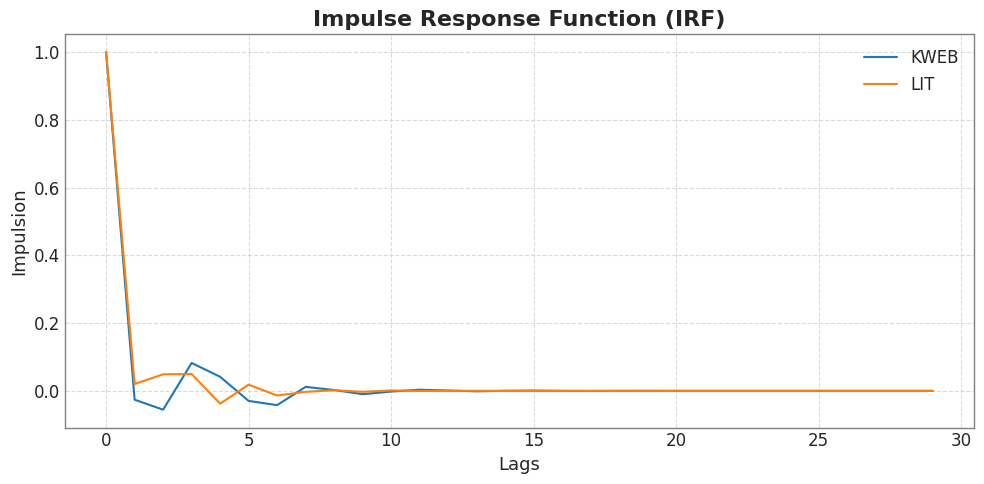

In [26]:
# Tracer les fonctions de réponse impulsionnelle (IRF) pour chaque ARIMA ajusté
n_periods = 30  # nombre de périodes pour l'IRF

plt.figure(figsize=(10, 5))
for etf, fitted in results.items():
    irf = [1]  # impulsion initiale
    for i in range(1, n_periods):
        # Utilise les coefficients AR estimés pour générer l'IRF
        arparams = fitted.arparams if hasattr(fitted, 'arparams') else []
        response = 0
        for lag, phi in enumerate(arparams, start=1):
            if i - lag >= 0:
                response += phi * irf[i - lag]
        irf.append(response)
    plt.plot(range(n_periods), irf, label=etf)

plt.title("Impulse Response Function (IRF)")
plt.xlabel("Lags")
plt.ylabel("Impulsion")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [32]:
from statsmodels.tsa.stattools import adfuller, kpss

etfs = ["KWEB", "LIT"]

for etf in etfs:
    print(f"\n===== Stationarity Tests for {etf} =====")
    
    # Bien recalculer log(price) pour chaque ETF
    series = np.log(df[etf]).dropna()

    # ADF test
    adf_stat, adf_p, *_ = adfuller(series)
    print(f"ADF test p-value: {adf_p:.4f} → {'Reject H0 → Stationary' if adf_p < 0.05 else 'Fail to reject H0 → Non-stationary'}")

    # KPSS test
    kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')
    print(f"KPSS test p-value: {kpss_p:.4f} → {'Reject H0 → Non-stationary' if kpss_p < 0.05 else 'Fail to reject H0 → Stationary'}")


===== Stationarity Tests for KWEB =====
ADF test p-value: 0.3282 → Fail to reject H0 → Non-stationary
KPSS test p-value: 0.0208 → Reject H0 → Non-stationary

===== Stationarity Tests for LIT =====
ADF test p-value: 0.6017 → Fail to reject H0 → Non-stationary
KPSS test p-value: 0.0100 → Reject H0 → Non-stationary


C:\Users\giann\AppData\Local\Temp\ipykernel_57860\74743682.py:16: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(series, regression='c', nlags='auto')


In [33]:
from statsmodels.tsa.stattools import coint

x = np.log(df["KWEB"]).dropna()
y = np.log(df["LIT"]).dropna()

# Alignement des dates (au cas où)
x, y = x.align(y, join='inner')

# Test de cointégration
coint_stat, p_value, crit_values = coint(x, y)

# Résultat
print("===== Engle-Granger Cointegration Test =====")
print(f"Test statistic: {coint_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print("Critical values:")
for level, val in zip(["1%", "5%", "10%"], crit_values):
    print(f"  {level}: {val:.4f}")

# Interprétation
if p_value < 0.05:
    print("\n✅ The two log-price series are cointegrated (reject H0).")
else:
    print("\n❌ The two series are not cointegrated (fail to reject H0).")

===== Engle-Granger Cointegration Test =====
Test statistic: -1.8547
p-value: 0.6028
Critical values:
  1%: -3.9176
  5%: -3.3479
  10%: -3.0526

❌ The two series are not cointegrated (fail to reject H0).
